# Dynamic Time Warping 

### Import librairies 

In [2]:
import numpy as np
from dtw import *
from sklearn.decomposition import PCA
import scipy.io

# from numpy.linalg import norm

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



### Toy example

Step pattern recursion:
 g[i,j] = min(
     g[i-3,j-2] +     d[i-2,j-1] +     d[i-1,j  ] +     d[i  ,j  ] ,
     g[i-1,j-1] +     d[i  ,j  ] ,
     g[i-2,j-3] +     d[i-1,j-2] +     d[i  ,j-1] + 0 * d[i  ,j  ] ,
 ) 

Normalization hint: N



<Axes: xlabel='Query index', ylabel='Reference index'>

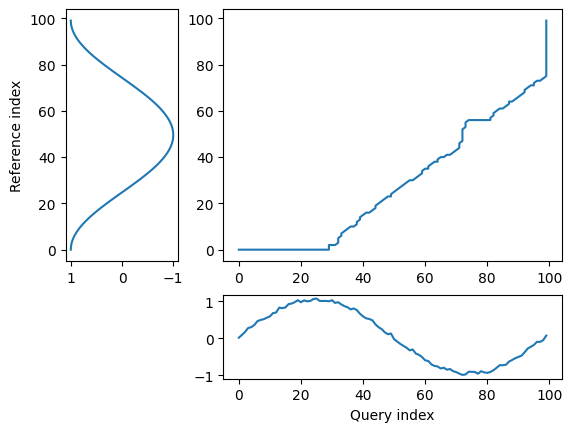

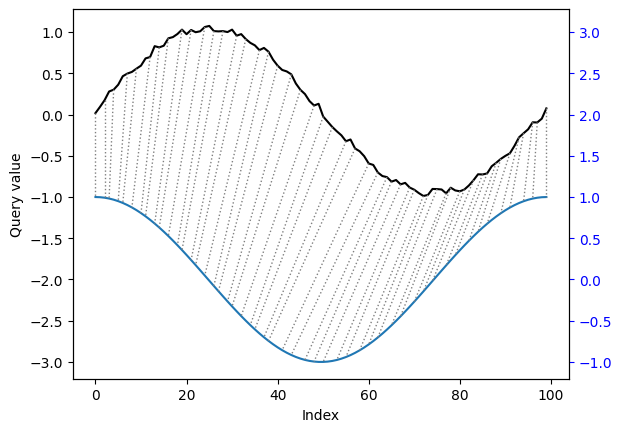

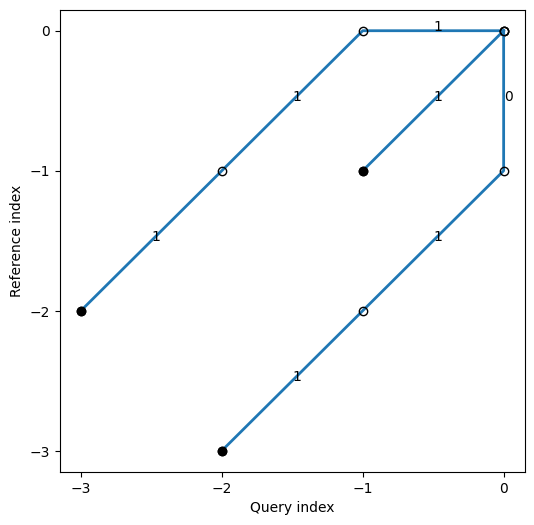

In [23]:
## A noisy sine wave as query
idx = np.linspace(0,6.28,num=100)
query = np.sin(idx) + np.random.uniform(size=100)/10.0

## A cosine is for template; sin and cos are offset by 25 samples
template = np.cos(idx)

## Find the best match with the canonical recursion formula
alignment = dtw(query, template, keep_internals=True)

## Display the warping curve, i.e. the alignment curve
alignment.plot(type="threeway")

## Align and plot with the Rabiner-Juang type VI-c unsmoothed recursion
dtw(query, template, keep_internals=True, 
    step_pattern=rabinerJuangStepPattern(6, "c"))\
    .plot(type="twoway",offset=-2)

## See the recursion relation, as formula and diagram
print(rabinerJuangStepPattern(6,"c"))
rabinerJuangStepPattern(6,"c").plot()

### First Try

shape of X8 =  (13,)
shape of X11 =  (11,)
Step pattern recursion:
 g[i,j] = min(
     g[i-3,j-2] +     d[i-2,j-1] +     d[i-1,j  ] +     d[i  ,j  ] ,
     g[i-1,j-1] +     d[i  ,j  ] ,
     g[i-2,j-3] +     d[i-1,j-2] +     d[i  ,j-1] + 0 * d[i  ,j  ] ,
 ) 

Normalization hint: N



<Axes: xlabel='Query index', ylabel='Reference index'>

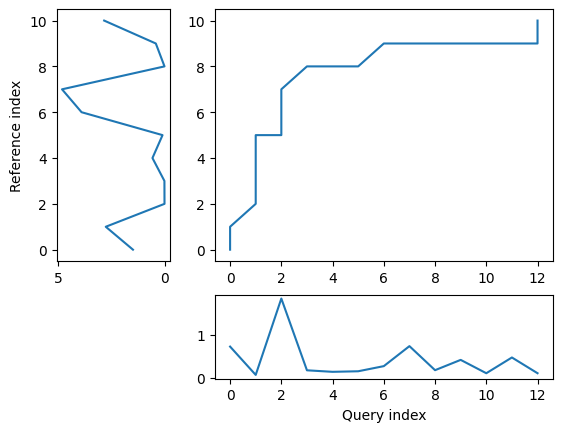

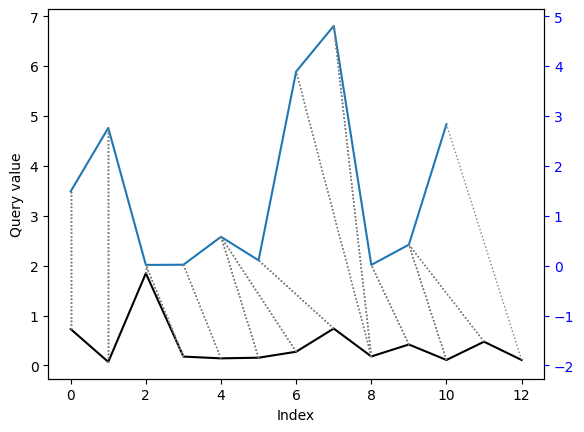

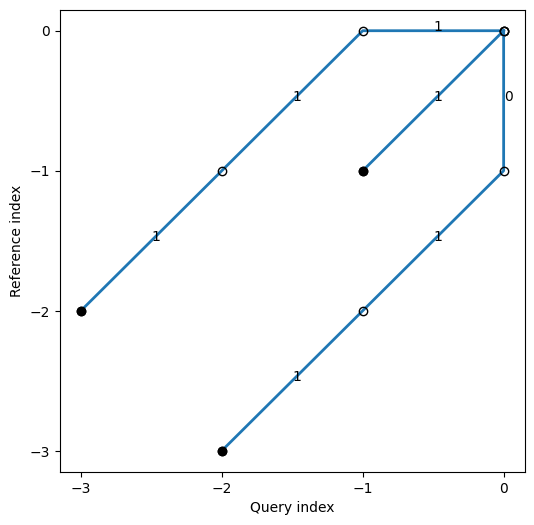

In [24]:
session = "run"
path_8 = "data/Rat8-20130713_proces_bin5.mat"
data_8 = scipy.io.loadmat(path_8)

path_11 = "data/Rat11-20150327_proces_bin5.mat"
data_11 = scipy.io.loadmat(path_11)

spk_sess_8 = data_8["spik"][session][0, 0].astype(float)   # neurons x T
# pos_sess = data["posit"][session][0, 0].astype(float)  # 2 x T on incorporera ça plus tard
# event_sess = data["event"][session][0, 0]              # 1 x T

spk_sess_11 = data_11["spik"][session][0, 0].astype(float)

# réduction (extrême) d'échantillons
X8 = spk_sess_8.mean(axis=1)
X11 = spk_sess_11.mean(axis=1)
 
# on divise par 20 les times bins
X8 = X8[::20]
X11 = X11[::20]

# 3. DTW avec contrainte
alignment = dtw(
    X8,
    X11,
    window_type="sakoechiba",
    window_args={"window_size": 100},
    keep_internals=True
)

alignment.plot(type="threeway")


print("shape of X8 = ", X8.shape)
print("shape of X11 = ", X11.shape)

dtw(X8, X11, keep_internals=True, step_pattern=rabinerJuangStepPattern(6, "c")).plot(type="twoway", offset=2)
print(rabinerJuangStepPattern(6, "c"))
rabinerJuangStepPattern(6, "c").plot()